# DDQN + Multi-Head Relational Attention on MiniGrid (Fully Observable)

对照实验: 用 `FullyObsWrapper` 替换 `ImgObsWrapper` 的 egocentric partial view.

- 观察从 7×7 自我中心 (代理隐式) 变成 grid_size × grid_size 全景 (代理显式, obj_type=10)
- 网络结构 / 损失 / 训练循环 / 超参数与 `Multihead.ipynb` 保持一致
- 唯一变量: 完全可观测 vs 部分可观测

**Note**: FullyObsWrapper 输出网格边长 = `grid_size` (对 DoorKey-5x5 是 5, 不是 7). 网络里 `N = grid_size**2` 而不是硬编码 49.

In [1]:
from einops import rearrange
import torch
from torch import nn
import numpy as np
import time
from collections import deque

import gymnasium as gym
from minigrid.wrappers import FullyObsWrapper, ImgObsWrapper

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

# 用 5×5 DoorKey; FullyObsWrapper 的输出网格 = 5 × 5
GRID_SIZE = 5
ENV_ID = 'MiniGrid-DoorKey-5x5-v0'

device: cuda


## 网络结构

跟 `Multihead.ipynb` 相同, 但 `N` 与 LayerNorm 的空间维度改成参数化, 支持不同 grid_size.

In [2]:
class MultiHeadRelationalModule(torch.nn.Module):
    def __init__(self, grid_size=5):
        # grid_size: FullyObsWrapper 输出的完整地图边长; DoorKey-5x5 是 5
        super().__init__()
        self.conv1_ch = 16
        self.conv2_ch = 20
        self.node_size = 64
        self.out_dim = 5
        self.ch_in = 3
        self.sp_coord_dim = 2
        self.N = grid_size * grid_size
        self.n_heads = 3

        self.conv1 = nn.Conv2d(self.ch_in, self.conv1_ch, kernel_size=(1,1), padding=0)
        self.conv2 = nn.Conv2d(self.conv1_ch, self.conv2_ch, kernel_size=(1,1), padding=0)

        self.proj_shape = (self.conv2_ch + self.sp_coord_dim, self.n_heads * self.node_size)
        self.k_proj = nn.Linear(*self.proj_shape)
        self.q_proj = nn.Linear(*self.proj_shape)
        self.v_proj = nn.Linear(*self.proj_shape)

        self.k_lin = nn.Linear(self.node_size, self.N)
        self.q_lin = nn.Linear(self.node_size, self.N)
        self.a_lin = nn.Linear(self.N, self.N)

        self.node_shape = (self.n_heads, self.N, self.node_size)
        self.k_norm = nn.LayerNorm(self.node_shape, elementwise_affine=True)
        self.q_norm = nn.LayerNorm(self.node_shape, elementwise_affine=True)
        self.v_norm = nn.LayerNorm(self.node_shape, elementwise_affine=True)

        self.linear1 = nn.Linear(self.n_heads * self.node_size, self.node_size)
        self.norm1 = nn.LayerNorm([self.N, self.node_size], elementwise_affine=True)
        self.linear2 = nn.Linear(self.node_size, self.out_dim)

    def forward(self, x):
        B, Cin, H, W = x.shape
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        with torch.no_grad():
            self.conv_map = x.clone()

        _, _, cH, cW = x.shape
        xcoords = torch.arange(cW, device=x.device).repeat(cH, 1).float() / cW
        ycoords = torch.arange(cH, device=x.device).repeat(cW, 1).transpose(1, 0).float() / cH
        spatial_coords = torch.stack([xcoords, ycoords], dim=0).unsqueeze(0).repeat(B, 1, 1, 1)

        x = torch.cat([x, spatial_coords], dim=1)
        x = x.permute(0, 2, 3, 1).flatten(1, 2)

        K = rearrange(self.k_proj(x), 'b n (head d) -> b head n d', head=self.n_heads)
        K = self.k_norm(K)
        Q = rearrange(self.q_proj(x), 'b n (head d) -> b head n d', head=self.n_heads)
        Q = self.q_norm(Q)
        V = rearrange(self.v_proj(x), 'b n (head d) -> b head n d', head=self.n_heads)
        V = self.v_norm(V)

        # 加性注意力
        A = torch.nn.functional.elu(self.k_lin(K) + self.q_lin(Q))
        A = self.a_lin(A)
        A = torch.nn.functional.softmax(A, dim=3)
        with torch.no_grad():
            self.att_map = A.clone()

        E = torch.einsum('bhfc,bhcd->bhfd', A, V)
        E = rearrange(E, 'b head n d -> b n (head d)')
        E = torch.relu(self.linear1(E))
        E = self.norm1(E)
        E = E.max(dim=1)[0]

        y = self.linear2(E)
        y = torch.nn.functional.elu(y)
        return y

## Helpers & 环境验证

In [3]:
def prepare_state(x: np.ndarray):
    # MiniGrid 返回 (W, H, C); permute(2, 0, 1) -> (C, W, H)
    ns = torch.from_numpy(x).float().permute(2, 0, 1).unsqueeze(dim=0)
    return ns.to(device)


def get_minibatch(replay, size):
    batch_ids = np.random.randint(0, len(replay), size)
    batch = [replay[i] for i in batch_ids]
    state_batch = torch.cat([e[0] for e in batch]).to(device)
    action_batch = torch.tensor([e[1] for e in batch], dtype=torch.long, device=device)
    reward_batch = torch.tensor([e[2] for e in batch], dtype=torch.float32, device=device)
    state2_batch = torch.cat([e[3] for e in batch]).to(device)
    done_batch = torch.tensor([e[4] for e in batch], dtype=torch.float32, device=device)
    return state_batch, action_batch, reward_batch, state2_batch, done_batch


def get_qtarget_ddqn(qvals, r, df, done):
    return r + (1 - done) * df * qvals


def lossfn(pred, targets, actions):
    q_sa = pred.gather(dim=1, index=actions.unsqueeze(dim=1))
    return torch.mean(torch.pow(targets.detach() - q_sa.squeeze(), 2))


def update_replay(replay, exp, replay_size):
    r = exp[2]
    N = 50 if r > 0 else 1
    for _ in range(N):
        replay.append(exp)
    return replay


action_map = {0: 0, 1: 1, 2: 2, 3: 3, 4: 5}

In [4]:
# 检查 FullyObsWrapper 的输出形状与内容
test_env = ImgObsWrapper(FullyObsWrapper(gym.make(ENV_ID)))
obs, _ = test_env.reset(seed=0)
print('obs shape:', obs.shape, '  (expected: ({0}, {0}, 3))'.format(GRID_SIZE))
print('object types seen:', sorted(set(obs[:, :, 0].flatten().tolist())))
ys, xs = np.where(obs[:, :, 0] == 10)
if len(ys):
    print(f'agent at (row={ys[0]}, col={xs[0]}), color/dir field = {obs[ys[0], xs[0], 1]}')
else:
    print('agent NOT found — FullyObsWrapper misconfigured')
test_env.close()

# 快速通网测试
m = MultiHeadRelationalModule(grid_size=GRID_SIZE).to(device)
with torch.no_grad():
    dummy = torch.randn(1, 3, GRID_SIZE, GRID_SIZE, device=device)
    out = m(dummy)
print('model forward test:', out.shape, '(expected: torch.Size([1, 5]))')

obs shape: (5, 5, 3)   (expected: (5, 5, 3))
object types seen: [1, 2, 4, 5, 8, 10]
agent at (row=1, col=3), color/dir field = 0
model forward test: torch.Size([1, 5]) (expected: torch.Size([1, 5]))


## 训练

In [5]:
losses = []
epochs_length = []

DEBUG_UNTIL = 20
DEBUG_EVERY = 500

env = ImgObsWrapper(FullyObsWrapper(gym.make(ENV_ID)))
state = prepare_state(env.reset()[0])

GWagent = MultiHeadRelationalModule(grid_size=GRID_SIZE).to(device)
Tnet = MultiHeadRelationalModule(grid_size=GRID_SIZE).to(device)
Tnet.load_state_dict(GWagent.state_dict())

maxsteps = 400
env.unwrapped.max_steps = maxsteps

epochs = 30000
replay_size = 9000
lr = 5e-4
gamma = 0.8
batch_size = 64

replay = deque(maxlen=replay_size)
opt = torch.optim.Adam(GWagent.parameters(), lr=lr)

eps = 0.5
update_freq = 100

t0 = time.time()
eps_len = 0

for i in range(epochs):
    eps_len += 1
    with torch.no_grad():
        pred = GWagent(state)
    action = int(torch.argmax(pred))
    if np.random.rand() < eps:
        action = int(torch.randint(0, 5, size=(1,)).squeeze())
    action_d = action_map[action]

    state2, reward, terminated, truncated, _ = env.step(action_d)
    state2 = prepare_state(state2)
    reward = -0.01 if reward == 0 else reward
    done = bool(terminated or truncated)
    exp = (state, action, reward, state2, done)
    replay = update_replay(replay, exp, replay_size)

    if i < DEBUG_UNTIL or i % DEBUG_EVERY == 0:
        q_np = pred.squeeze().cpu().numpy()
        spread = q_np.max() - q_np.min()
        print(f'i={i:5d} | Q={q_np.round(3)} spread={spread:.4f} '
              f'| a={action} r={reward:+.2f} term={terminated} trunc={truncated}')

    if done:
        state = prepare_state(env.reset()[0])
        env.unwrapped.max_steps = maxsteps
        epochs_length.append(eps_len)
        eps_len = 0
    else:
        state = state2

    if len(replay) > batch_size:
        opt.zero_grad()
        sb, ab, rb, s2b, db = get_minibatch(replay, batch_size)
        q_pred = GWagent(sb)
        astar = torch.argmax(q_pred, dim=1)
        qs = Tnet(s2b).gather(dim=1, index=astar.unsqueeze(dim=1)).squeeze()
        targets = get_qtarget_ddqn(qs.detach(), rb, gamma, db)
        loss = lossfn(q_pred, targets.detach(), ab)
        losses.append(loss.detach().cpu().item())

        if i < DEBUG_UNTIL or i % DEBUG_EVERY == 0:
            print(f'       train | loss={loss.item():.4f} '
                  f'| target mean={targets.mean().item():.3f} std={targets.std().item():.3f} '
                  f'| q_pred mean={q_pred.mean().item():.3f} std={q_pred.std().item():.3f} '
                  f'| rb mean={rb.mean().item():+.3f}')

        loss.backward()
        torch.nn.utils.clip_grad_norm_(GWagent.parameters(), max_norm=1.0)
        opt.step()

        if i % update_freq == 0:
            Tnet.load_state_dict(GWagent.state_dict())

    if (i + 1) % 2000 == 0:
        elapsed = time.time() - t0
        eta = elapsed / (i + 1) * (epochs - i - 1)
        recent = losses[-100:] if losses else []
        avg = sum(recent) / len(recent) if recent else float('nan')
        print(f'epoch {i+1}/{epochs} | elapsed {elapsed/60:.1f}min | ETA {eta/60:.1f}min | loss(avg100) {avg:.4f}')

print(f'done in {(time.time()-t0)/60:.1f} min')
print(f'positive-reward transitions in replay: {sum(1 for e in replay if e[2] > 0)} / {len(replay)}')
print(f'episodes completed: {len(epochs_length)}, min length: {min(epochs_length) if epochs_length else "n/a"}')

i=    0 | Q=[ 0.423  0.325 -0.339 -0.064  0.301] spread=0.7619 | a=3 r=-0.01 term=False trunc=False
i=    1 | Q=[ 0.423  0.325 -0.339 -0.064  0.301] spread=0.7619 | a=4 r=-0.01 term=False trunc=False
i=    2 | Q=[ 0.423  0.325 -0.339 -0.064  0.301] spread=0.7619 | a=4 r=-0.01 term=False trunc=False
i=    3 | Q=[ 0.423  0.325 -0.339 -0.064  0.301] spread=0.7619 | a=0 r=-0.01 term=False trunc=False
i=    4 | Q=[ 0.422  0.32  -0.34  -0.062  0.298] spread=0.7616 | a=0 r=-0.01 term=False trunc=False
i=    5 | Q=[ 0.419  0.331 -0.339 -0.072  0.297] spread=0.7579 | a=4 r=-0.01 term=False trunc=False
i=    6 | Q=[ 0.419  0.331 -0.339 -0.072  0.297] spread=0.7579 | a=4 r=-0.01 term=False trunc=False
i=    7 | Q=[ 0.419  0.331 -0.339 -0.072  0.297] spread=0.7579 | a=0 r=-0.01 term=False trunc=False
i=    8 | Q=[ 0.422  0.327 -0.339 -0.067  0.299] spread=0.7613 | a=0 r=-0.01 term=False trunc=False
i=    9 | Q=[ 0.423  0.325 -0.339 -0.064  0.301] spread=0.7619 | a=4 r=-0.01 term=False trunc=False


## 评估 (贪心)

In [6]:
GWagent.eval()
n_eval = 50
successes = 0
step_counts = []
returns = []

with torch.no_grad():
    for ep in range(n_eval):
        s = prepare_state(env.reset()[0])
        ep_return, steps, done = 0.0, 0, False
        while not done:
            q = GWagent(s)
            a = int(torch.argmax(q))
            s2, r, term, trunc, _ = env.step(action_map[a])
            ep_return += r
            steps += 1
            done = term or trunc
            s = prepare_state(s2)
        if term and ep_return > 0:
            successes += 1
        step_counts.append(steps)
        returns.append(ep_return)

print(f'success rate: {successes}/{n_eval} = {successes/n_eval:.1%}')
print(f'avg steps:    {np.mean(step_counts):.1f}')
print(f'avg return:   {np.mean(returns):.3f}')
GWagent.train()

success rate: 0/50 = 0.0%
avg steps:    400.0
avg return:   0.000


MultiHeadRelationalModule(
  (conv1): Conv2d(3, 16, kernel_size=(1, 1), stride=(1, 1))
  (conv2): Conv2d(16, 20, kernel_size=(1, 1), stride=(1, 1))
  (k_proj): Linear(in_features=22, out_features=192, bias=True)
  (q_proj): Linear(in_features=22, out_features=192, bias=True)
  (v_proj): Linear(in_features=22, out_features=192, bias=True)
  (k_lin): Linear(in_features=64, out_features=25, bias=True)
  (q_lin): Linear(in_features=64, out_features=25, bias=True)
  (a_lin): Linear(in_features=25, out_features=25, bias=True)
  (k_norm): LayerNorm((3, 25, 64), eps=1e-05, elementwise_affine=True, bias=True)
  (q_norm): LayerNorm((3, 25, 64), eps=1e-05, elementwise_affine=True, bias=True)
  (v_norm): LayerNorm((3, 25, 64), eps=1e-05, elementwise_affine=True, bias=True)
  (linear1): Linear(in_features=192, out_features=64, bias=True)
  (norm1): LayerNorm((25, 64), eps=1e-05, elementwise_affine=True, bias=True)
  (linear2): Linear(in_features=64, out_features=5, bias=True)
)

In [7]:
import random
GWagent.eval()
print('=== Q-values across 5 replay states ===')
with torch.no_grad():
    for j, exp in enumerate(random.sample(list(replay), min(5, len(replay)))):
        s = exp[0]
        q = GWagent(s).squeeze().cpu().numpy()
        print(f'state {j}: Q={q.round(4)} spread={q.max()-q.min():.4f}')

print('\n=== synthetic inputs ===')
with torch.no_grad():
    z = torch.zeros(1, 3, GRID_SIZE, GRID_SIZE, device=device)
    o = torch.ones(1, 3, GRID_SIZE, GRID_SIZE, device=device) * 5
    r = torch.rand(1, 3, GRID_SIZE, GRID_SIZE, device=device) * 10
    print(f'zeros:  Q={GWagent(z).squeeze().cpu().numpy().round(4)}')
    print(f'fives:  Q={GWagent(o).squeeze().cpu().numpy().round(4)}')
    print(f'random: Q={GWagent(r).squeeze().cpu().numpy().round(4)}')
GWagent.train()

=== Q-values across 5 replay states ===
state 0: Q=[-0.048  -0.0517 -0.0261 -0.0457 -0.0486] spread=0.0256
state 1: Q=[-0.048  -0.0517 -0.0261 -0.0457 -0.0486] spread=0.0256
state 2: Q=[-0.0473 -0.0509 -0.0241 -0.045  -0.0475] spread=0.0268
state 3: Q=[-0.0482 -0.0537 -0.0307 -0.0475 -0.0486] spread=0.0230
state 4: Q=[-0.048  -0.052  -0.0266 -0.0459 -0.0485] spread=0.0254

=== synthetic inputs ===
zeros:  Q=[-0.0225 -0.0154  0.0334 -0.0156 -0.015 ]
fives:  Q=[-0.0694 -0.0482 -0.1715 -0.0579 -0.0895]
random: Q=[-0.0317 -0.0048 -0.1266 -0.0144 -0.0554]


MultiHeadRelationalModule(
  (conv1): Conv2d(3, 16, kernel_size=(1, 1), stride=(1, 1))
  (conv2): Conv2d(16, 20, kernel_size=(1, 1), stride=(1, 1))
  (k_proj): Linear(in_features=22, out_features=192, bias=True)
  (q_proj): Linear(in_features=22, out_features=192, bias=True)
  (v_proj): Linear(in_features=22, out_features=192, bias=True)
  (k_lin): Linear(in_features=64, out_features=25, bias=True)
  (q_lin): Linear(in_features=64, out_features=25, bias=True)
  (a_lin): Linear(in_features=25, out_features=25, bias=True)
  (k_norm): LayerNorm((3, 25, 64), eps=1e-05, elementwise_affine=True, bias=True)
  (q_norm): LayerNorm((3, 25, 64), eps=1e-05, elementwise_affine=True, bias=True)
  (v_norm): LayerNorm((3, 25, 64), eps=1e-05, elementwise_affine=True, bias=True)
  (linear1): Linear(in_features=192, out_features=64, bias=True)
  (norm1): LayerNorm((25, 64), eps=1e-05, elementwise_affine=True, bias=True)
  (linear2): Linear(in_features=64, out_features=5, bias=True)
)

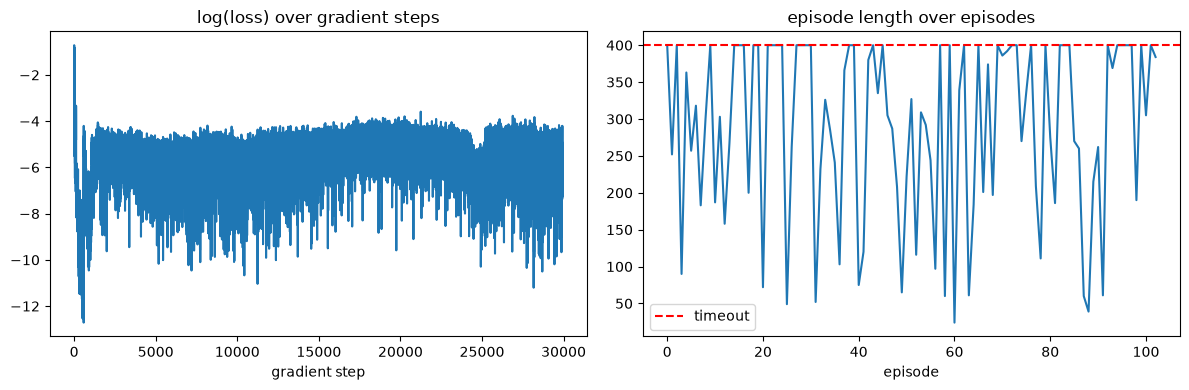

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if losses:
    axes[0].plot(np.log(np.clip(np.array(losses), 1e-8, None)))
    axes[0].set_title('log(loss) over gradient steps')
    axes[0].set_xlabel('gradient step')
if epochs_length:
    axes[1].plot(epochs_length)
    axes[1].set_title('episode length over episodes')
    axes[1].set_xlabel('episode')
    axes[1].axhline(400, color='red', linestyle='--', label='timeout')
    axes[1].legend()
plt.tight_layout()
plt.show()